<a href="https://colab.research.google.com/github/mmetee/python_2026/blob/main/Polynomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-459/2847148778.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(list(tickers.values()), period='1y')['Close']
[*********************100%***********************]  4 of 4 completed


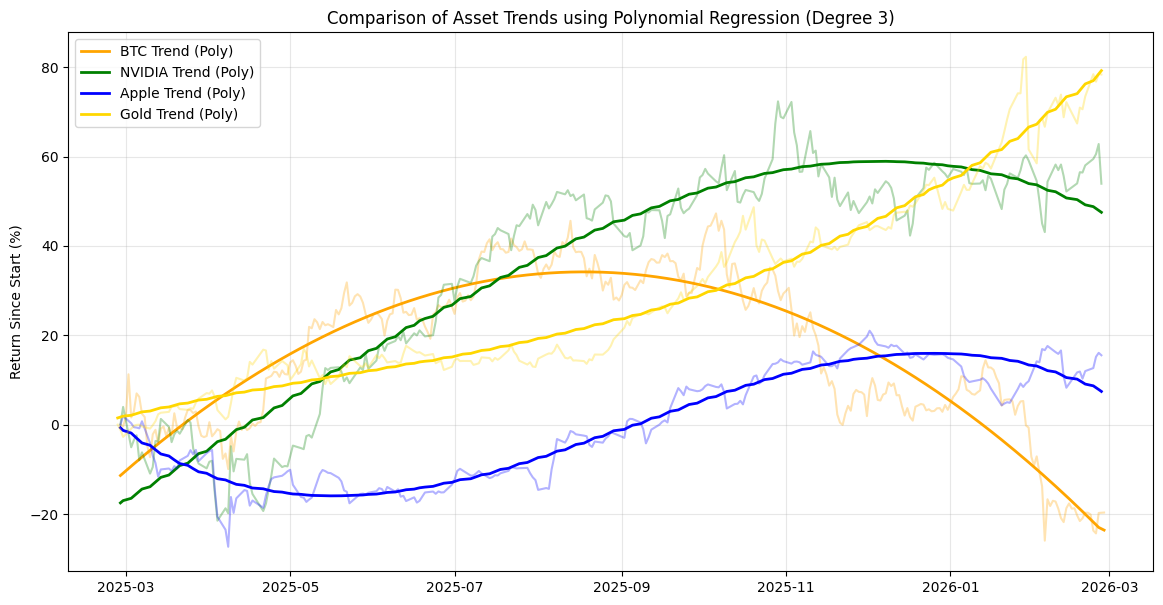

In [4]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pandas as pd

# 1. ดึงข้อมูลย้อนหลัง 1 ปี (จนถึงปัจจุบัน กุมภาพันธ์ 2026)
tickers = {'BTC': 'BTC-USD', 'NVIDIA': 'NVDA', 'Apple': 'AAPL', 'Gold': 'GC=F'}
data = yf.download(list(tickers.values()), period='1y')['Close']

# 2. ปรับข้อมูลให้เป็นอัตราการเติบโต (%) เพื่อให้เปรียบเทียบกันได้ (Normalize)
# เนื่องจากราคา BTC หลักล้าน แต่หุ้นหลักร้อย การเทียบ % จะเห็นภาพชัดกว่า
# แก้ไข: ปรับการ Normalization ให้ใช้ค่าแรกที่ไม่ใช่ NaN ของแต่ละคอลัมน์
data_norm = data.apply(lambda x: (x / x.dropna().iloc[0] - 1) * 100)

# 3. ฟังก์ชันสร้าง Polynomial Regression
def fit_polynomial(y_data, degree=3):
    X = np.arange(len(y_data)).reshape(-1, 1)
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y_data)
    return model.predict(X_poly)

# 4. พล็อตกราฟเปรียบเทียบ
plt.figure(figsize=(14, 7))
colors = ['orange', 'green', 'blue', 'gold']

for i, (name, ticker) in enumerate(tickers.items()):
    actual = data_norm[ticker].dropna()
    # ตรวจสอบว่ามีข้อมูลเพียงพอสำหรับการทำ Polynomial Regression หรือไม่
    if len(actual) > 3: # 'degree' is defined in fit_polynomial, use a generic check
        trend = fit_polynomial(actual, degree=3) # ใช้ Degree 3 เพื่อดูความโค้ง S-curve
        plt.plot(actual.index, actual, alpha=0.3, color=colors[i]) # กราฟจริง (จางๆ)
        plt.plot(actual.index, trend, label=f'{name} Trend (Poly)', color=colors[i], linewidth=2)
    else:
        print(f"Warning: Not enough data for {name} to perform Polynomial Regression with degree 3. Skipping trend plot.")
        plt.plot(actual.index, actual, label=f'{name} (Actual)', color=colors[i], linewidth=1)

plt.title('Comparison of Asset Trends using Polynomial Regression (Degree 3)')
plt.ylabel('Return Since Start (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# New Section